# INITIALIZING

In [38]:
#------------IMPORTS------------#
import os
import toml
import numpy as np
import hera_pspec as hp
from pathlib import Path
import random
import helpers
import plotting
import matplotlib.pyplot as plt
import papermill as pm
from decimal import Decimal

In [39]:
#------------LOADING TOML CONFIGS------------#

TOML_FILE = os.environ.get('TOML_FILE',
        '/home/Kwuzard/Projects/HERA_HONS/src/HONS/h6c_pspec_11band.toml')

# Load configuration from the toml and inject into globals.
toml_options = toml.load(TOML_FILE)
for toml_section in ['GLOBAL_OPTS', 'POSTPROCESS_AND_PSPEC_OPTS']:
    if toml_section not in toml_options:
        continue
    print(f'\nLoading config from [{toml_section}] in {TOML_FILE}:')
    for key, val in toml_options[toml_section].items():
        globals()[key.upper()] = val
        print(f'  {key.upper()} = {val!r}')


Loading config from [GLOBAL_OPTS] in /home/Kwuzard/Projects/HERA_HONS/src/HONS/h6c_pspec_11band.toml:
  FM_LOW_FREQ = 87.5
  FM_HIGH_FREQ = 108.0
  EIGENVAL_CUTOFF = 1e-12
  AUTO_FR_SPECTRUM_FILE = '/lustre/aoc/projects/hera/zmartino/hera_frf/spectra_cache/spectra_cache_hera_auto.h5'
  MIN_SAMP_FRAC = 0.05
  BAND_STR = '50.2~62.2,63.3~73.5,74.6~85.4,117.3~124.4,125.4~136.2,159.3~169.9,171.9~181.1,212.3~220.6'
  LST_MIN = -1.5
  LST_MAX = 15.5

Loading config from [POSTPROCESS_AND_PSPEC_OPTS] in /home/Kwuzard/Projects/HERA_HONS/src/HONS/h6c_pspec_11band.toml:
  PLOT = True
  SAVE_RESULTS = True
  ALREADY_INPAINTED = True
  PERFORM_INPAINT = False
  INPAINT_MIN_DLY = 500.0
  INPAINT_HORIZON = 1.0
  INPAINT_STANDOFF = 0.0
  INPAINT_EIGENVAL_CUTOFF = 1e-12
  PERFORM_DLY_FILT = False
  DLY_FILT_MIN_DLY = 25
  DLY_FILT_HORIZON = 1.0
  DLY_FILT_STANDOFF = 0
  DLY_FILT_EIGENVAL_CUTOFF = 1e-12
  USE_BAND_AVG_NSAMPLES = True
  FM_CUT_FREQ = 100000000.0
  FM_GAP_LOW = 85400000.0
  FM_GAP_HIGH = 

In [40]:
#------------GLOBAL CONSTANTS------------#
IS_INPAINT_HERE = False
IS_LOG_SCALE_POWER = False
IS_FLAGS_OFF = False
SAVE_PLOTS = True
IS_PLOT_SIGNAL_LOSS = True
SAVE_CSV_FILES = False

#------------SECTIONAL SETTINGS----------#
IS_VALIDATION_TESTS = True
IS_EXPERIMENTAL_TESTS = False
IS_SIGNAL_LOSS_TEST = True


# FUNCTIONS

## HELPER FUNCTIONS

In [41]:
def format_folder_value(value, significant_digits=6):
    """
    Canonical numerical format for folder names.

    Examples:
        1.0        -> "1"
        0.9        -> "0.9"
        0.9000001  -> "0.9"
        0.0001     -> "0.0001"
        1e-12      -> "1e-12"
    """
    value = Decimal(str(value))

    # General format uses significant digits and switches to
    # scientific notation for sufficiently small/large values.
    formatted = format(value, f".{significant_digits}g")

    # Always use lowercase scientific notation.
    return formatted.replace("E", "e")

## PLOTTING FUNCTIONS

In [42]:
def plot_signal_loss(
    bl_pair_name,
    unfiltered_pspec,
    filtered_pspecs,
    horizon_hw,
    filter_hw,
    signal_loss_tolerance,
    signal_loss_scaled_limits=False,
    labels=None
):

    SPW_TO_PLOT = [0, 7]
    PLOT_EV_CUT = [0, 1, 2, 3, 4 ,5, 6, 7, 8, 9]

    if labels is None:
        labels = [str(i) for i in range(len(filtered_pspecs))]

    psc_unfiltered = hp.PSpecContainer(
        unfiltered_pspec,
        mode="r"
    )

    uvp_unfiltered_folded = psc_unfiltered.get_pspec(
        "stokespol",
        "time_and_interleave_averaged"
    )

    uvp_unfiltered_folded.fold_spectra()
    #Reversing arrays because we want smallest ev cutoff to appear at the of other lines
    labels = labels[::-1]
    filtered_pspecs = filtered_pspecs[::-1]

    PLOT_EV_CUT = [
        len(filtered_pspecs) - 1 - i
        for i in PLOT_EV_CUT
    ]
    
    for spw_to_plot in SPW_TO_PLOT:

        plt.figure(figsize=(8, 5), dpi=100)

        for i, filtered_pspec in enumerate(filtered_pspecs):
            if not i in PLOT_EV_CUT : continue
            psc_filtered = hp.PSpecContainer(
                filtered_pspec,
                mode="r"
            )

            uvp_filtered_folded = psc_filtered.get_pspec(
                "stokespol",
                "time_and_interleave_averaged"
            )

            uvp_filtered_folded.fold_spectra()

            for key in uvp_filtered_folded.get_all_keys():

                if key[0] != spw_to_plot:
                    continue

                P_filtered = np.squeeze(
                    uvp_filtered_folded.get_data(key)
                )

                P_unfiltered = np.squeeze(
                    uvp_unfiltered_folded.get_data(key)
                )

                signal_loss = np.nan_to_num(
                    1.0 - (np.abs(P_filtered) / np.abs(P_unfiltered)),
                    posinf=0.0,
                    neginf=0.0
                )

                delays = np.squeeze(
                    uvp_filtered_folded.get_dlys(spw_to_plot)
                )

                delays_ns = delays * 1e9

                plt.plot(
                    delays_ns,
                    signal_loss,
                    linewidth=2,
                    label=f"EV cutoff: {labels[i]}"
                )

            psc_filtered._close()

        plt.axhline(
            y=signal_loss_tolerance,
            linestyle="--",
            color = "black",
            label="Tolerance"
        )

        plt.axvline(
            x=filter_hw,
            linestyle="-.",
            color = "black",
            label="Nominal half-width"
        )

        plt.axvline(
            x=horizon_hw,
            linestyle=":",
            color = "black",
            label="Baseline horizon"
        )

        plt.title(
            f"(Folded) Signal loss ({bl_pair_name}) for SPW {spw_to_plot} with filter hw = {filter_hw / horizon_hw:.1f} x horizon"
        )

        plt.xlabel("Delay (ns)")

        plt.ylabel(
            r"Signal loss = "
            r"$1-|P_{\mathrm{filt}}|/|P_{\mathrm{unfiltered}}|$"
        )

        plt.legend(loc="upper right")

        plt.grid(axis="y", alpha=0.3)

        if signal_loss_scaled_limits:
            plt.ylim(
                top = signal_loss_tolerance * 1.2
            )
        else:
            plt.ylim(bottom=0.0)

        plt.xlim(left = 0, right = 2000)
        plt.tight_layout()
        plt.show()

    psc_unfiltered._close()

## SIGNAL LOSS TEST FUNCTIONS

In [43]:
def get_critical_delay_for_signal_loss(
    unfiltered_pspec,
    delay_filtered_sum_pspec,
    signal_loss_tolerance):
    psc_filtered = hp.PSpecContainer(delay_filtered_sum_pspec, mode="r")
    psc_unfiltered = hp.PSpecContainer(unfiltered_pspec, mode = "r")

    """PURPOSE: Calculates the average delay cutoff at which furthermore signal loss is less
            than the defined tolerance"""

    uvp_filtered_folded = psc_filtered.get_pspec(
        "stokespol",
        "time_and_interleave_averaged"
    )

    uvp_unfiltered_folded = psc_unfiltered.get_pspec(
        "stokespol",
        "time_and_interleave_averaged"
    )

    uvp_filtered_folded.fold_spectra()
    uvp_unfiltered_folded.fold_spectra()

    delay_intersects_windows = []
    for key in uvp_filtered_folded.get_all_keys():
        P_filtered = uvp_filtered_folded.get_data(key)
        P_unfiltered = uvp_unfiltered_folded.get_data(key)

        P_filtered = np.squeeze(P_filtered)
        P_unfiltered = np.squeeze(P_unfiltered)

        signal_loss = 1.0 - (
            np.abs(P_filtered)
            / np.abs(P_unfiltered)
        )

        delays = np.squeeze(
            uvp_filtered_folded.get_dlys(key[0])
        )

        delays_ns = delays * 1e9

        # Find the furthest delay where signal loss is still
        # greater than the allowed tolerance
        valid_delays = delays_ns[
            signal_loss >= signal_loss_tolerance
        ]

        if len(valid_delays) > 0:
            delay_intersect = np.max(valid_delays)
        else:
            delay_intersect = delays_ns[-1] # Give intersect very far out (Basically, "This spw is not within tolerance")
        delay_intersects_windows.append(delay_intersect)

    psc_filtered._close()
    psc_unfiltered._close()

    return np.max(delay_intersects_windows)


def signal_loss_test(dir_to_datasets, dir_to_output, is_eor=False):
    # Eigenvalue cutoffs swept for every filter half-width fraction, in ascending order.
    #
    # Small cutoffs keep many DPSS modes (K > 2NW): the filter edge sits beyond the nominal
    # half-width and more signal is lost. Cutoffs near 1 keep only the well-concentrated modes
    # (K <~ 2NW): the edge is sharper and closer to the nominal half-width, but the fit can
    # under-resolve foregrounds within the wedge
    EIGENVALUE_CUTOFFS = [
        1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-2,   # loose: my original sweep
        0.5, 0.9, 0.99, 0.999,                          # tight: keep only modes with lambda > cutoff
    ]
    ACCEPTABLE_SIGNAL_LOSS = 0.03  # 3% of signal may be lost.

    DELAY_HW_MIN_FRACT = 0.1
    DELAY_HW_MAX_FRACT = 1.0
    DELAY_HW_FRACT_DECR = 0.1

    directory_to_eor_and_foregrounds = (
        dir_to_datasets / "eor_and_foregrounds" if is_eor else dir_to_datasets
    )
    directory_to_eor_only_datasets = (
        dir_to_datasets / "eor_only" if is_eor else None
    )
    directory_comparative_plots = dir_to_output / "comparative_plots"

    dir_pspec_out = dir_to_output / "out_pspec"
    dir_off_delay = dir_pspec_out / "delay_off"
    dir_on_delay = dir_pspec_out / "delay_on"

    dir_to_datasets.mkdir(parents=True, exist_ok=True)
    dir_to_output.mkdir(parents=True, exist_ok=True)
    dir_pspec_out.mkdir(parents=True, exist_ok=True)
    directory_to_eor_and_foregrounds.mkdir(parents=True, exist_ok=True)

    if SAVE_PLOTS:
        directory_comparative_plots.mkdir(parents=True, exist_ok=True)
    if is_eor:
        directory_to_eor_only_datasets.mkdir(parents=True, exist_ok=True)

    bl_pspec_kept = []

    for input_file in directory_to_eor_and_foregrounds.glob("*.uvh5"):

        pair = input_file.name.split(".")[3]
        bl_pair_folder_name = "BLPAIR_" + pair
        ant1, ant2 = pair.split("_")

        if ant1 == ant2:
            continue  # Skip autocorrelations

        # ------------------------------------------------------------------ #
        # Directories
        # ------------------------------------------------------------------ #
        bl_pair_folder_delay_off = dir_off_delay / bl_pair_folder_name
        bl_pair_folder_delay_on = dir_on_delay / bl_pair_folder_name
        bl_pair_comparative_plots_folder = (
            directory_comparative_plots / bl_pair_folder_name
        )
        bl_pair_comparative_plots_scaled_folder = (
            bl_pair_comparative_plots_folder / "LOG"
            if IS_LOG_SCALE_POWER
            else bl_pair_comparative_plots_folder / "NON-LOG"
        )

        bl_pair_folder_delay_off.mkdir(parents=True, exist_ok=True)
        bl_pair_folder_delay_on.mkdir(parents=True, exist_ok=True)
        if SAVE_PLOTS:
            bl_pair_comparative_plots_folder.mkdir(parents=True, exist_ok=True)
            bl_pair_comparative_plots_scaled_folder.mkdir(parents=True, exist_ok=True)

        # ------------------------------------------------------------------ #
        # File paths
        # ------------------------------------------------------------------ #
        eor_only_input_file = directory_to_eor_only_datasets / input_file.name
        unfiltered_pspec = (
            bl_pair_folder_delay_off / f"{input_file.stem}.tavg.pspec.h5"
        )

        file_to_use = input_file if not is_eor else eor_only_input_file

        # ------------------------------------------------------------------ #
        # PSPEC for unfiltered data
        # ------------------------------------------------------------------ #
        if not unfiltered_pspec.is_file():
            print(f"Processing file without delay filter : {input_file.name}")
            try:
                pm.execute_notebook(
                    "single_baseline_postprocessing_and_pspec.ipynb",
                    bl_pair_folder_delay_off / "sbpp_output.ipynb",
                    parameters={
                        "INPUT_FILE": str(file_to_use),
                        "OUTPUT_DIR": str(bl_pair_folder_delay_off.absolute()),
                        "PERFORM_DLY_FILT": False,
                        "PERFORM_INPAINT": False,
                    },
                )
            except Exception as e:
                print(f"Exception in notebook execution: {type(e).__name__}: {e}")
        else:
            print(f"Skipping existing no-delay pspec: {unfiltered_pspec.name}")

        # The baseline horizon is defined ONLY by the 1.0 x horizon configuration and
        # does not change with delay_filt_hw_fract. It is read from hw.csv after the
        # 1.0 x horizon folders have been generated.
        baseline_horizon_hw = None
        found_suitable_config = False
        delay_filt_hw_fract = DELAY_HW_MAX_FRACT

        # ------------------------------------------------------------------ #
        # Loop over filter half-width fractions
        # ------------------------------------------------------------------ #
        while delay_filt_hw_fract >= DELAY_HW_MIN_FRACT:

            hw_fract_name = format_folder_value(delay_filt_hw_fract)

            dir_hw_frac = (
                bl_pair_folder_delay_on / f"hw_fract_{hw_fract_name}"
            )

            dir_hw_frac.mkdir(parents=True, exist_ok=True)

            # Per-cutoff results for this half-width (same order as EIGENVALUE_CUTOFFS)
            filtered_pspecs = []
            delay_criticals = []
            pspec_labels = []

            # -------------------------------------------------------------- #
            # Loop over eigenvalue cutoffs
            # -------------------------------------------------------------- #
            for eigenval_cutoff in EIGENVALUE_CUTOFFS:

                ev_cutoff_name = format_folder_value(eigenval_cutoff)
                dir_ev_cutoff = (
                    dir_hw_frac / f"ev_cutoff_{ev_cutoff_name}"
                )

                dir_ev_cutoff.mkdir(parents=True, exist_ok=True)

                filtered_pspec = dir_ev_cutoff / f"{input_file.stem}.tavg.pspec.h5"

                if not filtered_pspec.is_file():
                    print(f"Processing file with delay filter : {input_file.name}")
                    try:
                        pm.execute_notebook(
                            "single_baseline_postprocessing_and_pspec.ipynb",
                            dir_ev_cutoff / "sbpp_output.ipynb",
                            parameters={
                                "INPUT_FILE": str(file_to_use),
                                "OUTPUT_DIR": str(dir_ev_cutoff.absolute()),
                                "PERFORM_DLY_FILT": True,
                                "HW_OUT_DIR": str(dir_ev_cutoff.absolute()),
                                "DLY_FILT_HW_FRACT": delay_filt_hw_fract,
                                "PERFORM_INPAINT": False,
                                "DLY_FILT_EIGENVAL_CUTOFF": eigenval_cutoff,
                            },
                        )
                    except Exception as e:
                        print(
                            f"Exception in notebook execution: "
                            f"{type(e).__name__}: {e}"
                        )
                else:
                    print(f"Skipping existing delay-filtered pspec: {filtered_pspec.name}")

                # Signal-loss test for THIS cutoff
                delay_critical = get_critical_delay_for_signal_loss(
                    unfiltered_pspec,
                    filtered_pspec,
                    ACCEPTABLE_SIGNAL_LOSS,
                )

                filtered_pspecs.append(filtered_pspec)
                delay_criticals.append(delay_critical)
                pspec_labels.append(str(eigenval_cutoff))

            # -------------------------------------------------------------- #
            # Establish the baseline horizon ONLY after completing the
            # 1.0 x horizon EV-cutoff loop.
            # -------------------------------------------------------------- #
            if baseline_horizon_hw is None and np.isclose(
                delay_filt_hw_fract, DELAY_HW_MAX_FRACT
            ):
                ev_cutoff_folders = [
                    folder
                    for folder in dir_hw_frac.iterdir()
                    if folder.is_dir() and (folder / "hw.csv").is_file()
                ]
                if not ev_cutoff_folders:
                    raise FileNotFoundError(
                        f"No EV-cutoff folders containing hw.csv "
                        f"were found in {dir_hw_frac}"
                    )

                selected_ev_folder = random.choice(ev_cutoff_folders)
                with open(selected_ev_folder / "hw.csv") as hw_file:
                    line = hw_file.readline().strip().split(",")
                    baseline_horizon_hw = float(line[1])

                print(
                    f"\nBaseline horizon for {bl_pair_folder_name}: "
                    f"{baseline_horizon_hw:.6f} ns"
                )
                print(f"Obtained from: {selected_ev_folder}\n")

            # The FILTER half-width changes with hw_fract; the BASELINE HORIZON does not.
            filter_hw = baseline_horizon_hw * delay_filt_hw_fract

            # -------------------------------------------------------------- #
            # Pick a suitable configuration.
            #
            # Every cutoff is tested against its own critical delay. Among those
            # that pass, take the SMALLEST cutoff (most DPSS modes, so the most
            # foreground removal that still meets the signal-loss criterion).
            # -------------------------------------------------------------- #
            passing = [
                i for i, d in enumerate(delay_criticals)
                if d <= baseline_horizon_hw
            ]

            if passing:
                i = passing[0]  # EIGENVALUE_CUTOFFS is ascending
                chosen_cutoff = EIGENVALUE_CUTOFFS[i]

                print(f"The critical delay was: {delay_criticals[i]:.3f}\n")
                print(f"Found suitable config for baseline {bl_pair_folder_name}:\n")
                print(f"Baseline horizon: {baseline_horizon_hw:.6f} ns")
                print(
                    f"Filter hw: {delay_filt_hw_fract} x "
                    f"{baseline_horizon_hw:.6f} = {filter_hw:.6f} ns"
                )
                print(f"Eigenvalue cutoff: {chosen_cutoff}\n")

                bl_pspec_kept.append([
                    bl_pair_folder_name,
                    filtered_pspecs[i],
                    unfiltered_pspec,
                    baseline_horizon_hw,
                    filter_hw,
                    chosen_cutoff,
                ])
                found_suitable_config = True
                break

            # -------------------------------------------------------------- #
            # No cutoff passed at this half-width: plot all cutoffs.
            # Horizon is FIXED, filter HW moves.
            # -------------------------------------------------------------- #
            plot_signal_loss(
                bl_pair_folder_name,
                unfiltered_pspec,
                filtered_pspecs,
                baseline_horizon_hw,
                filter_hw,
                ACCEPTABLE_SIGNAL_LOSS,
                signal_loss_scaled_limits=False,
                labels=pspec_labels,
            )

            delay_filt_hw_fract -= DELAY_HW_FRACT_DECR

    # ---------------------------------------------------------------------- #
    # Plot configurations that were ultimately kept
    # ---------------------------------------------------------------------- #
    for (bl_pair_name, filtered_pspec, unfiltered_pspec,
         baseline_horizon_hw, hw_used, ev_cutoff_used) in bl_pspec_kept:

        if IS_PLOT_SIGNAL_LOSS:
            plot_signal_loss(
                bl_pair_name,
                unfiltered_pspec,
                [filtered_pspec],
                baseline_horizon_hw,
                hw_used,
                ACCEPTABLE_SIGNAL_LOSS,
                signal_loss_scaled_limits=True,
                labels=[str(ev_cutoff_used)],
            )

        print(
            f"{bl_pair_name} kept with configuration "
            f"[HW: {hw_used}, EV_CUTT: {ev_cutoff_used}]"
        )

# SIGNAL LOSS TESTS

### SIGNAL LOSS TESTING (VALIDATION DATA)

Skipping existing no-delay pspec: zen.LST.baseline.0_7.sum.tavg.pspec.h5
Processing file with delay filter : zen.LST.baseline.0_7.sum.uvh5


Executing:   0%|          | 0/131 [00:00<?, ?cell/s]

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.
Task exception was never retrieved
future: <Task finished name='Task-916' coro=<NotebookClient._async_poll_kernel_alive() done, defined at /home/Kwuzard/Projects/HERA_HONS/.venv/lib/python3.10/site-packages/nbclient/client.py:821> exception=AssertionError()>
Traceback (most recent call last):
  File "/home/Kwuzard/Projects/HERA_HONS/.venv/lib/python3.10/site-packages/nbclient/client.py", line 825, in _async_poll_kernel_alive
    await self._async_check_alive()
  File "/home/Kwuzard/Projects/HERA_HONS/.venv/lib/python3.10/site-packages/nbclient/client.py", line 861, in _async_check_alive
    assert self.kc is not None
AssertionError
Task exception was never retrieved
future: <Task finished name='Task-1123' co

Processing file with delay filter : zen.LST.baseline.0_7.sum.uvh5


Executing:   0%|          | 0/131 [00:00<?, ?cell/s]

...

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


Processing file with delay filter : zen.LST.baseline.0_7.sum.uvh5


Executing:   0%|          | 0/131 [00:00<?, ?cell/s]

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.



Baseline horizon for BLPAIR_0_7: 341.088035 ns
Obtained from: /home/Kwuzard/Projects/HERA_HONS/output/signal_loss_test_out/validation/out_pspec/delay_on/BLPAIR_0_7/hw_fract_1.0/ev_cutoff_0.999



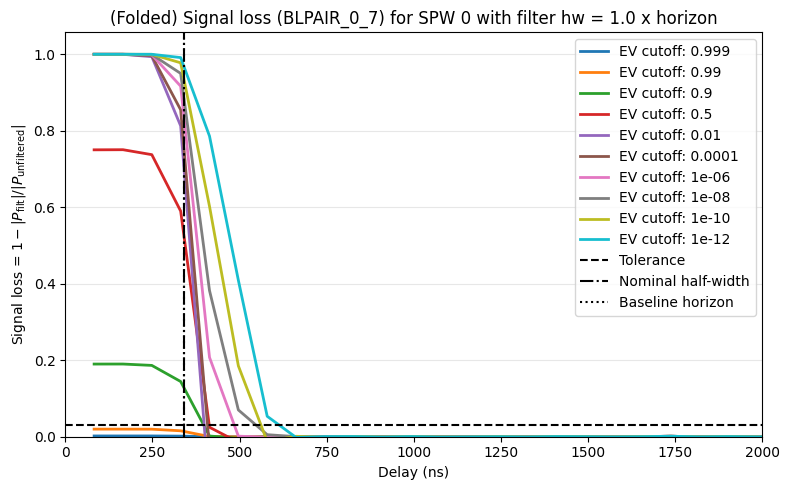

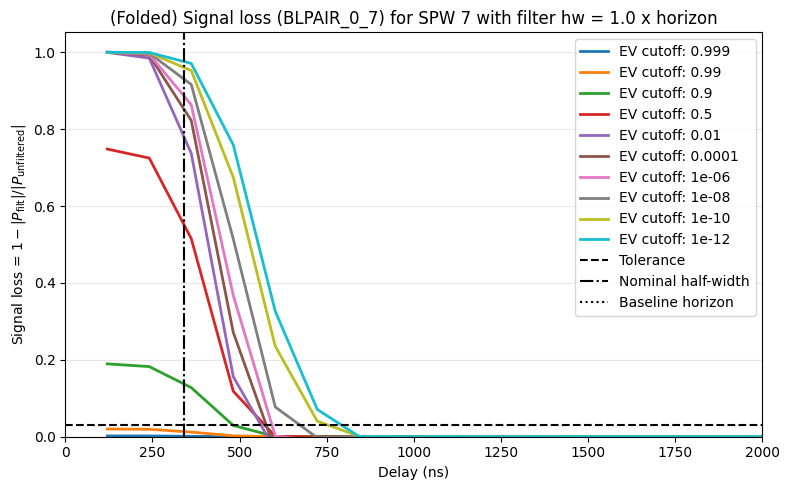

Processing file with delay filter : zen.LST.baseline.0_7.sum.uvh5


Executing:   0%|          | 0/131 [00:00<?, ?cell/s]

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


Processing file with delay filter : zen.LST.baseline.0_7.sum.uvh5


Executing:   0%|          | 0/131 [00:00<?, ?cell/s]

...

Executing:   0%|          | 0/131 [00:00<?, ?cell/s]

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


Processing file with delay filter : zen.LST.baseline.0_7.sum.uvh5


Executing:   0%|          | 0/131 [00:00<?, ?cell/s]

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


In [ ]:
if IS_VALIDATION_TESTS :
    directory_to_validation_datasets = Path.cwd().parent.parent / "validation_data"
    directory_to_validation_output = Path.cwd().parent.parent / "output" / "signal_loss_test_out" / "validation"
    
    signal_loss_test(
        directory_to_validation_datasets,
        directory_to_validation_output,
        is_eor = True,
    )

### SIGNAL LOSS TEST (EXPERIMENTAL)

In [ ]:
if IS_EXPERIMENTAL_TESTS:
    directory_to_datasets = Path.cwd().parent.parent / "raw_data" / "single_baselines_raw_data"
    directory_to_output = Path.cwd().parent.parent / "output" / "signal_loss_test_out" / "experimental"

    print(directory_to_datasets)
    print(directory_to_output)
    
    signal_loss_test(
        directory_to_datasets,
        directory_to_output,
        is_eor = False
    )